In [4]:
import os
import sys

import matplotlib.pyplot as plt
import xarray as xr
import easygems.healpix as egh

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from regional_timeseries import domains, sims, get_rainfall
from utils import get_nn_lon_lat_index, haversine, hp_mods, hp_to_latlon

region="SAm"


SyntaxError: incomplete input (1794554237.py, line 1)

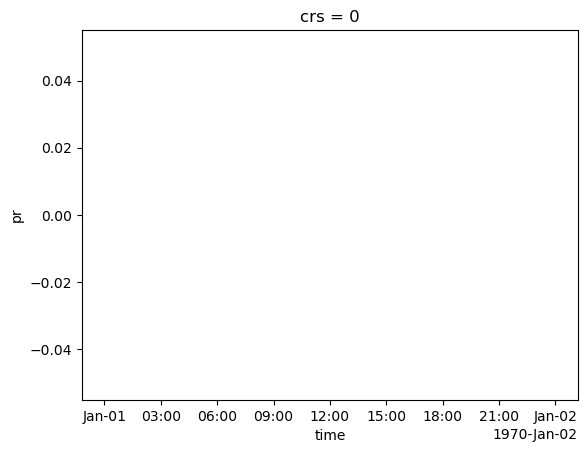

In [ ]:
xr.open_dataarray("um_glm_n2560_RAL3p3_tuned_hk26_SAm_zoom_7.nc").plot()

In [1]:
for sim in ["icon_d3hp003"]:
    precip = xr.open_dataarray(f"{sim}_{region}_zoom_7.nc")
    precip.plot(label=sim)


NameError: name 'xr' is not defined

In [18]:
precip = xr.open_dataarray(f"{sim}_{region}_zoom_7.nc")
plt.plot(precip.data)


In [5]:
        zoom=3
        lonmin = domains[region]["lonmin"]
        lonmax = domains[region]["lonmax"]
        latmin = domains[region]["latmin"]
        latmax = domains[region]["latmax"]
        for sim in sims:
            print(sim)
            outdir = f"precip/{sim}_{region}_zoom_{zoom}.nc"
            pr = (
                get_rainfall(sim, zoom)
                .sel(longitude=slice(lonmin, lonmax), latitude=slice(latmin, latmax)))
            )
            print(pr.longitude)

um_glm_n2560_RAL3p3_tuned_hk26


/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.DataArray 'longitude' (longitude: 49)> Size: 392B
array([   0. ,    7.5,   15. ,   22.5,   30. ,   37.5,   45. ,   52.5,   60. ,
         67.5,   75. ,   82.5,   90. ,   97.5,  105. ,  112.5,  120. ,  127.5,
        135. ,  142.5,  150. ,  157.5,  165. ,  172.5, -180. , -172.5, -165. ,
       -157.5, -150. , -142.5, -135. , -127.5, -120. , -112.5, -105. ,  -97.5,
        -90. ,  -82.5,  -75. ,  -67.5,  -60. ,  -52.5,  -45. ,  -37.5,  -30. ,
        -22.5,  -15. ,   -7.5,    0. ])
Coordinates:
    crs        int64 8B 0
  * longitude  (longitude) float64 392B 0.0 7.5 15.0 22.5 ... -15.0 -7.5 0.0
ifs_tco3999-ng5_rcbmf


/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


NameError: name 'ifs_hp_mods' is not defined

<xarray.DataArray 'pr' (time: 9745, latitude: 25, longitude: 49)> Size: 48MB
dask.array<transpose, shape=(9745, 25, 49), dtype=float32, chunksize=(1024, 15, 49), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
    crs        int64 8B 0
    cell       (latitude, longitude) int64 10kB 512 512 512 512 ... 255 255 63
    lat        (latitude, longitude) float64 10kB -84.15 -84.15 ... 84.15 84.15
    lon        (latitude, longitude) float64 10kB 45.0 45.0 45.0 ... 315.0 45.0
  * latitude   (latitude) float64 200B -90.0 -82.5 -75.0 ... 75.0 82.5 90.0
  * longitude  (longitude) float64 392B 0.0 7.5 15.0 22.5 ... 345.0 352.5 360.0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 4, 203]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['stratiform_rainfall_flux', 'stratiform_snowfall_flux']
    notes:          Combined rain and snow. Hourly mean - time index shifted ...
    grid_mapping:   crs

In [6]:
import intake
url = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
cat = intake.open_catalog(url)["online"]
sim_cat = cat[sim]
[sim for sim in cat]

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'arp-gem-1p3km',
 'arp-gem-2p6km',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'ifs_tco3999_rcbmf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_CoMA9_hk26',

In [32]:
sim_cat = cat["ifs_tco3999-ng5_rcbmf"]
rain = sim_cat(zoom=7).to_dask().pipe(egh.attach_coords).tp
# egh.healpix_show(rain.sel(time="2020-02-25").mean(dim="time"))

/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [33]:
rain=rain.assign_coords({"cell":rain.value}).rename({"value":"cell"}).set_xindex("cell")
# rain.set_index(value="cell")
rain

/tmp/ipykernel_2638/3413757972.py:1: UserWarning: rename 'value' to 'cell' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  rain=rain.assign_coords({"cell":rain.value}).rename({"value":"cell"}).set_xindex("cell")


<xarray.DataArray 'tp' (time: 10201, cell: 196608)> Size: 16GB
dask.array<open_dataset-tp, shape=(10201, 196608), dtype=float64, chunksize=(85, 196608), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01 ... 2021-03-01
    crs      int64 8B 0
  * cell     (cell) int64 2MB 0 1 2 3 4 5 ... 196603 196604 196605 196606 196607
Attributes: (12/15)
    paramId:                    228
    dataType:                   fc
    numberOfPoints:             196608
    typeOfLevel:                surface
    stepUnits:                  1
    stepType:                   accum
    ...                         ...
    name:                       Total precipitation
    cfVarName:                  tp
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150
    grid_mapping:               crs

In [26]:
rain

<xarray.DataArray 'tp' (time: 10201, value: 196608)> Size: 16GB
dask.array<open_dataset-tp, shape=(10201, 196608), dtype=float64, chunksize=(85, 196608), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 82kB 2020-01-01 ... 2021-03-01
    crs      int64 8B 0
    cell     (value) int64 2MB 0 1 2 3 4 ... 196603 196604 196605 196606 196607
Dimensions without coordinates: value
Attributes: (12/15)
    paramId:                    228
    dataType:                   fc
    numberOfPoints:             196608
    typeOfLevel:                surface
    stepUnits:                  1
    stepType:                   accum
    ...                         ...
    name:                       Total precipitation
    cfVarName:                  tp
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150
    grid_mapping:               crs

In [12]:
sim_cat = cat["um_glm_n2560_RAL3p3_tuned_hk26"]
rain = sim_cat(zoom=7).to_dask().pipe(egh.attach_coords).pr
# egh.healpix_show(rain.sel(time="2020-02-25").mean(dim="time"))
rain

/home/users/franmorr/miniforge3/envs/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.DataArray 'pr' (time: 9745, healpix_index: 196608)> Size: 8GB
dask.array<open_dataset-pr, shape=(9745, 196608), dtype=float32, chunksize=(64, 16384), chunktype=numpy.ndarray>
Coordinates:
  * healpix_index  (healpix_index) int64 2MB 0 1 2 3 ... 196605 196606 196607
  * time           (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
    crs            int64 8B 0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 4, 203]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['stratiform_rainfall_flux', 'stratiform_snowfall_flux']
    notes:          Combined rain and snow. Hourly mean - time index shifted ...
    grid_mapping:   crs